# TrendLens — 03 · Clustering (Phase 3)

Stage 5–7: dimensionality reduction comparison, HDBSCAN clustering, cluster reporting, representative images + contact sheets.

> **Research-integrity note:** we **measure** whether reduction helps rather than assuming it — HDBSCAN on raw 512-d vs on UMAP-10d. All engagement numbers are synthetic demo data.

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd()
if not (REPO / "config.py").exists():
    for p in Path.cwd().parents:
        if (p / "config.py").exists():
            REPO = p; break
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import clustering

## 1 · Load embeddings (never hard-code the dimension)

In [2]:
emb = clustering.load_embeddings()
meta = clustering.load_aligned_metadata()
print("embeddings:", emb.shape, emb.dtype)
print("metadata:", meta.shape)
assert len(emb) == len(meta)
assert emb.shape[1] == 512  # inspect actual shape, then assert expectation

embeddings: (5000, 512) float32
metadata: (5000, 27)


## 2 · Experiment A: HDBSCAN directly on raw embeddings

In [3]:
labels_a, probs_a, cl_a = clustering.run_hdbscan(
    emb, min_cluster_size=50, min_samples=10,
    save_model=clustering.config.CLUSTER_MODELS_DIR / "hdbscan_raw.pkl",
)
stats_a = clustering.cluster_report(emb, labels_a, probs_a, cl_a)

HDBSCAN(min_cluster_size=50, min_samples=10, method=eom) in 61.5s: 2 clusters, 4549 noise
Saved model manifest -> /home/akriti/Documents/Project/trendlens/artifacts/cluster_models/hdbscan_raw.pkl
CLUSTER REPORT
points      : 5,000
clusters    : 2
noise       : 4,549 (91.0%)
clustered   : 9.0%
cluster sizes (desc): c0=397, c1=54
persistence (top): c0=0.034, c1=0.025
silhouette  : 0.1704796552658081


## 3 · Experiment B: UMAP-10d then HDBSCAN

UMAP output is cached (`.npy`) so this runs once.

In [4]:
reduced = clustering.reduce_dimensions(emb, method="umap", n_components=10)
labels_b, probs_b, cl_b = clustering.run_hdbscan(
    reduced, min_cluster_size=50, min_samples=10,
    save_model=clustering.config.CLUSTER_MODELS_DIR / "hdbscan_umap10.pkl",
)
stats_b = clustering.cluster_report(reduced, labels_b, probs_b, cl_b)

Loading cached umap (10d): umap_10d.npy


HDBSCAN(min_cluster_size=50, min_samples=10, method=eom) in 0.3s: 29 clusters, 1322 noise
Saved model manifest -> /home/akriti/Documents/Project/trendlens/artifacts/cluster_models/hdbscan_umap10.pkl
CLUSTER REPORT
points      : 5,000
clusters    : 29
noise       : 1,322 (26.4%)
clustered   : 73.6%
cluster sizes (desc): c25=369, c20=325, c7=256, c21=218, c16=212, c18=199, c28=182, c1=170, c0=168, c5=138, c23=133, c17=115, c11=110, c13=98, c10=82, c22=82, c8=79, c26=79, c4=77, c3=66, c24=65, c15=63, c6=62, c9=59, c19=59, c14=54, c27=54, c2=53, c12=51
persistence (top): c4=0.849, c10=0.595, c6=0.581, c0=0.559, c1=0.534, c13=0.507, c5=0.495, c2=0.331, c23=0.264, c11=0.247
silhouette  : 0.586135745048523


## 4 · Raw vs reduced — honest comparison

On this 5K subset, **reduction clearly helps**: raw embeddings give 2 clusters / 91% noise (high-dimensional HDBSCAN collapse), UMAP-10d gives 29 clusters / 26% noise with silhouette ≈ 0.59. This is why we never assume — we measure.

In [5]:
rows = []
for name, s in [("A: raw 512d", stats_a), ("B: UMAP-10d", stats_b)]:
    rows.append({
        "setup": name,
        "n_clusters": s["n_clusters"],
        "noise_%": round(s["noise_pct"] * 100, 1),
        "silhouette": None if s["silhouette"] is None else round(s["silhouette"], 3),
    })
pd.DataFrame(rows)

,setup,n_clusters,noise_%,silhouette
0,A: raw 512d,2,91.0,0.170
1,B: UMAP-10d,29,26.4,0.586


## 5 · Parameter sweep (sensitivity)

In [6]:
sweep = clustering.parameter_sweep(reduced, [50, 100, 200], [10, 25])
sweep

HDBSCAN(min_cluster_size=50, min_samples=10, method=eom) in 0.3s: 29 clusters, 1322 noise


HDBSCAN(min_cluster_size=50, min_samples=25, method=eom) in 0.3s: 23 clusters, 1129 noise


HDBSCAN(min_cluster_size=100, min_samples=10, method=eom) in 0.3s: 3 clusters, 0 noise


HDBSCAN(min_cluster_size=100, min_samples=25, method=eom) in 0.3s: 3 clusters, 0 noise


HDBSCAN(min_cluster_size=200, min_samples=10, method=eom) in 0.3s: 2 clusters, 0 noise


HDBSCAN(min_cluster_size=200, min_samples=25, method=eom) in 0.3s: 2 clusters, 0 noise


,min_cluster_size,min_samples,method,n_clusters,noise_pct,clustered_pct,silhouette
0,50,10,eom,29,0.2644,0.7356,0.593515
1,50,25,eom,23,0.2258,0.7742,0.552368
2,100,10,eom,3,0.0000,1.0000,0.568899
3,100,25,eom,3,0.0000,1.0000,0.568899
4,200,10,eom,2,0.0000,1.0000,0.595358
5,200,25,eom,2,0.0000,1.0000,0.595358


## 6 · Cluster summary (synthetic demo engagement)

In [7]:
summary = clustering.cluster_summary(meta, labels_b, probs_b)
summary.head(10)

,cluster_id,size,percentage,mean_probability,median_engagement,mean_engagement
0,0,168,0.0336,0.860194,46.0,68.964286
1,1,170,0.0340,0.866192,44.0,81.494118
2,2,53,0.0106,0.988672,40.0,82.415094
3,3,66,0.0132,0.991542,43.0,77.166667
4,4,77,0.0154,0.938831,50.0,76.818182
5,5,138,0.0276,0.651961,45.0,69.101449
6,6,62,0.0124,0.915682,45.0,66.161290
7,7,256,0.0512,0.945282,51.0,89.335938
8,8,79,0.0158,0.844834,39.0,56.734177
9,9,59,0.0118,0.973122,42.0,66.067797


## 7 · Representative images + contact sheets

In [8]:
reps = clustering.representative_images(meta, emb, labels_b, probs_b, k=9)
clustering.save_representatives(reps)
sheets = clustering.contact_sheets(reps)
print(f"contact sheets: {len(sheets)}")

Contact sheets:   0%|          | 0/29 [00:00<?, ?it/s]

contact sheets: 29


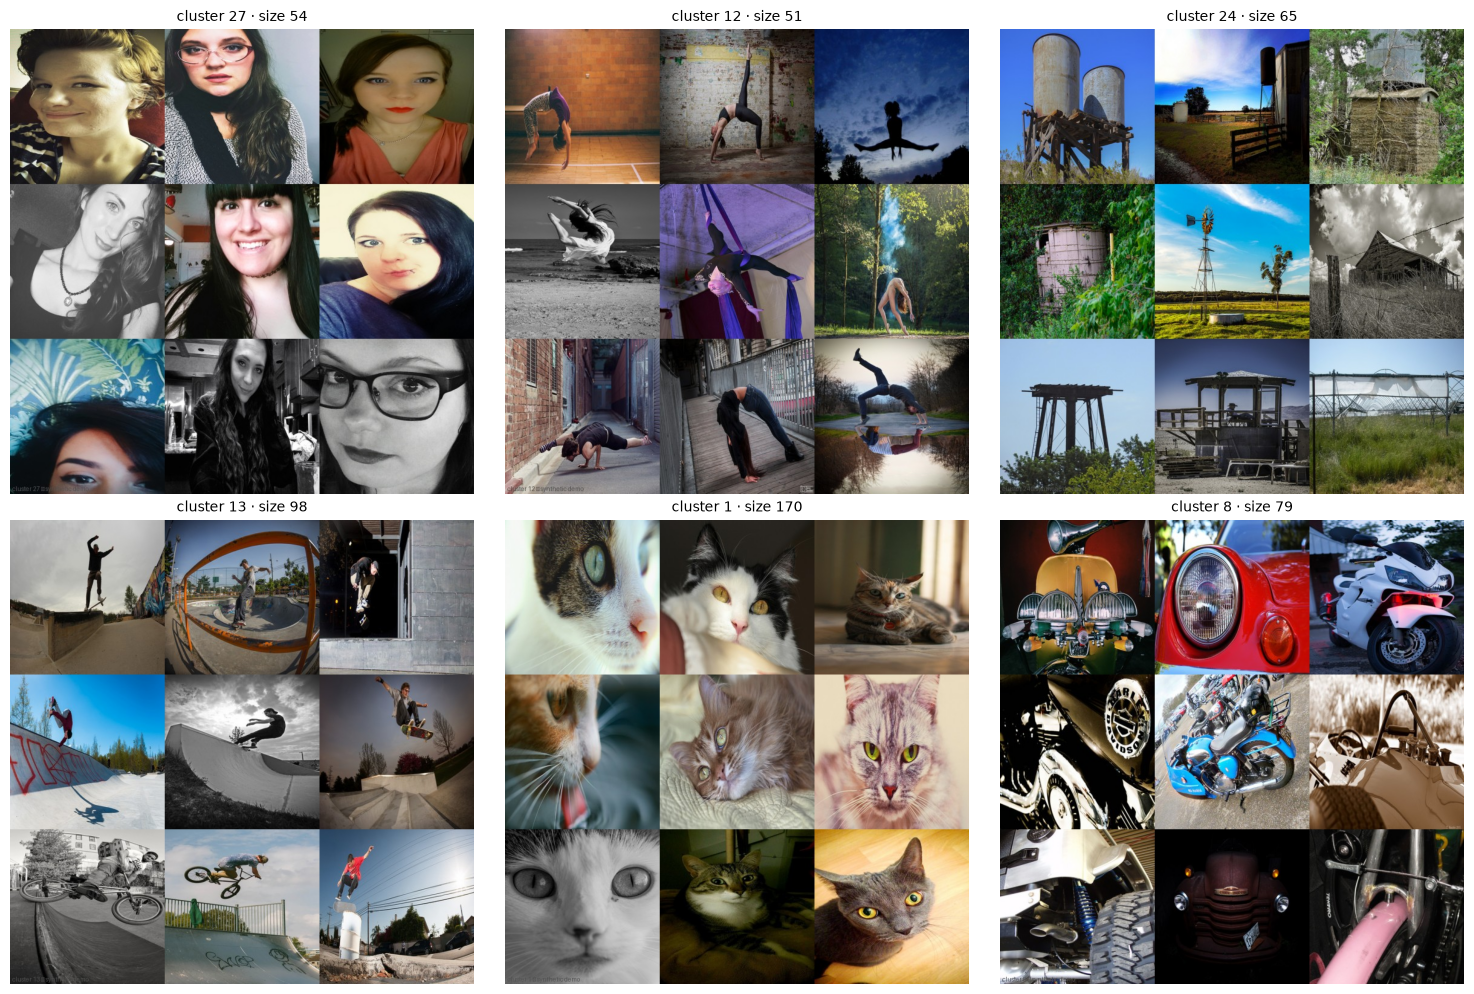

In [9]:
from PIL import Image
import random
sample_clusters = random.Random(0).sample(sorted(sheets), min(6, len(sheets)))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, c in zip(axes.flat, sample_clusters):
    ax.imshow(Image.open(sheets[c]))
    ax.set_title(f"cluster {c} · size {summary.loc[summary.cluster_id==c,'size'].values[0]}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Phase 3 checkpoint
- [x] Raw vs reduced HDBSCAN comparison (measured, not assumed)
- [x] Parameter sweep
- [x] Cluster report: sizes, noise, persistence, silhouette
- [x] Representative images + contact sheets (29 clusters)

**Next (Phase 4):** temporal trend detection on these clusters (with neutral synthetic timestamps — no rigged lifecycles).